<a href="https://colab.research.google.com/github/kritikagg/MyFirst3DProject/blob/main/APP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **AI POWERED FOOD ANALYZER**

Please mount your drive using this code snippet. Kindly Ensure that the model is uploaded on the drive and the path on the code is edited accordingly.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Run the following code to fetch results.

**APP.PY**

Loading weights from /content/drive/MyDrive/food_analyzer_model (1).keras...
 Weights loaded successfully.

Starting camera viewer. Please grant access and wait for capture.

Image successfully captured and saved as '/content/captured_fruit.jpg'.

Predicting image: /content/captured_fruit.jpg

Prediction: **BANANA**
Confidence: **45.91%**

Nutritional Analysis for: BANANA
Enter the approximate weight of the banana in grams (g) [Default: 100g]: 40

Attempting to fetch real-time data for banana...
Data successfully retrieved from external API.

****************************************
NUTRITIONAL SUMMARY for 40g of banana:
****************************************
| Metric | Value |
|:--------------------|:--------------|
|  Total Calories   | **64.4 kcal**|
|  Protein          | 0.3 g    |
|  Fat              | 1.3 g        |
|  Carbohydrates    | 13.0 g      |
****************************************
(Data provided as an estimate. Sourced via API or local fallback.)


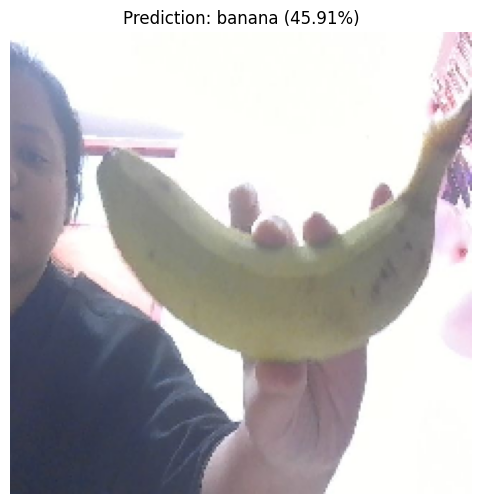

In [ ]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import requests
import os

# --- Colab Specific Imports for Camera ---
from IPython.display import display, Javascript
from google.colab.output import eval_js
from base64 import b64decode
import io

IMAGE_SIZE = (224, 224)
class_names = ['apple', 'avocado', 'banana', 'cherry', 'kiwi', 'mango', 'orange', 'pineapple', 'strawberries', 'watermelon']
num_classes = len(class_names)

NUTRITION_DATA_PER_100G = {
    'apple': [52, 0.3, 0.2, 13.8],
    'avocado': [160, 2.0, 14.7, 8.5],
    'banana': [89, 1.1, 0.3, 22.8],
    'cherry': [50, 1.0, 0.3, 12.0],
    'kiwi': [61, 1.1, 0.5, 14.7],
    'mango': [60, 0.8, 0.4, 15.0],
    'orange': [47, 0.9, 0.1, 11.8],
    'pineapple': [50, 0.5, 0.1, 13.0],
    'strawberries': [32, 0.7, 0.3, 7.7],
    'watermelon': [30, 0.6, 0.2, 7.6]
}

# NOTE: Replace with your actual key if different
API_KEY = "QcO51jcmC9u4cbT42NJHVcA7cDKaLJozB1yu76kc"
NUTRITION_API_ENDPOINT = "https://api.nal.usda.gov/fdc/v1/foods/search"

data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip('horizontal'),
    tf.keras.layers.RandomRotation(0.2),
])
preprocess_input = tf.keras.applications.mobilenet_v2.preprocess_input

base_model = tf.keras.applications.MobileNetV2(
    input_shape=(*IMAGE_SIZE, 3),
    include_top=False,
    weights='imagenet'
)
base_model.trainable = False

inputs = tf.keras.Input(shape=(*IMAGE_SIZE, 3))
x = preprocess_input(inputs)
x = base_model(x, training=False)
x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.Dropout(0.2)(x)
outputs = tf.keras.layers.Dense(num_classes, activation='softmax')(x)
model = tf.keras.Model(inputs, outputs)

# --- Load Model Weights ---
#update model_path by copying the path of the model from the mounted drive
model_path = '/content/drive/MyDrive/food_analyzer_model (1).keras'
print(f"Loading weights from {model_path}...")

if not os.path.exists(model_path):
    print(f" ERROR: Model file not found at '{model_path}'.")
    print("Please make sure the file exists at that exact path in your Google Drive.")
else:
    try:
        model.load_weights(model_path)
        print(" Weights loaded successfully.")
    except Exception as e:
        print(f" ERROR loading weights: {e}")

# ----------------------------------------------------------------------
# CAMERA CAPTURE FUNCTION (Robust Implementation) ---
# ----------------------------------------------------------------------

def capture_and_save_image(filename='captured_fruit.jpg', quality=0.8):
    """
    Captures an image from the user's webcam in a Google Colab notebook
    and saves it to a file in the local runtime.
    Returns the absolute path to the saved image file.
    """
    print(f"\nStarting camera viewer. Please grant access and wait for capture.")

    js_code = Javascript('''
        (async function() {
            google.colab.output.setIframeHeight(0, true, {maxHeight: 480});
            const div = document.createElement('div');
            const video = document.createElement('video');
            video.style.display = 'block';

            // Access camera
            const stream = await navigator.mediaDevices.getUserMedia({video: true});
            document.body.appendChild(div);
            div.appendChild(video);
            video.srcObject = stream;

            // Wait for video load/play
            await new Promise((resolve) => video.onloadedmetadata = resolve);
            await new Promise((resolve) => video.play().then(resolve));

            const canvas = document.createElement('canvas');
            canvas.width = video.videoWidth;
            canvas.height = video.videoHeight;

            // Wait 3 seconds for positioning
            console.log("Capturing image in 3 seconds...");
            await new Promise(resolve => setTimeout(resolve, 3000));

            // Draw frame
            canvas.getContext('2d').drawImage(video, 0, 0, video.videoWidth, video.videoHeight);

            // Stop stream and clean up
            stream.getVideoTracks()[0].stop();
            div.remove();

            // Return Base64 data from the IIFE scope
            return canvas.toDataURL('image/jpeg', %f);
        })()
    ''' % quality)

    data = None
    try:
        data = eval_js(js_code.data)
    except Exception as e:
        print(f"\n ERROR: Camera capture failed. Did you grant camera permission? Details: {e}")
        return None

    if data:
        try:
            binary = b64decode(data.split(',')[1])
            full_path = f'/content/{filename}'
            with open(full_path, 'wb') as f:
                f.write(binary)

            print(f"\nImage successfully captured and saved as '{full_path}'.")
            return full_path

        except Exception as e:
            print(f"\n ERROR during file saving/decoding: {e}")
            return None
    return None

# ----------------------------------------------------------------------
# --- Prediction Function  ---
# ----------------------------------------------------------------------

def predict_image(model, img_path, class_names):
    if not img_path:
        return None, None, None

    print(f"\nPredicting image: {img_path}")

    if not os.path.exists(img_path):
        print(f" ERROR: Test image not found at '{img_path}'.")
        print("Please ensure the image was saved correctly.")
        return None, None, None

    img = tf.keras.utils.load_img(
        img_path, target_size=IMAGE_SIZE
    )
    img_array = tf.keras.utils.img_to_array(img)
    img_batch = np.expand_dims(img_array, axis=0)

    predictions = model.predict(img_batch, verbose=0)

    predicted_class_index = np.argmax(predictions[0])
    predicted_class_name = class_names[predicted_class_index]
    confidence_score = 100 * np.max(predictions[0])

    return predicted_class_name, confidence_score, img

# ----------------------------------------------------------------------
# --- Nutrition Functions ---
# ----------------------------------------------------------------------

def fetch_nutrition_from_api(food_name, weight_g):
    print(f"\nAttempting to fetch real-time data for {food_name}...")

    try:
        params = {
            'query': food_name,
            'api_key': API_KEY,
            'pageSize': 1,
            'dataType': ["Survey (FNDDS)"]
        }

        response = requests.get(NUTRITION_API_ENDPOINT, params=params, timeout=10)
        response.raise_for_status()

        data = response.json()

        if data and 'foods' in data and len(data['foods']) > 0:
            food_data = data['foods'][0]
            nutrients = food_data.get('foodNutrients', [])

            calories, protein, fat, carbs = 0.0, 0.0, 0.0, 0.0

            for nutrient in nutrients:
                name = nutrient.get('nutrientName', '').lower()
                amount_per_100g = nutrient.get('value', 0)

                if 'energy' in name and nutrient.get('unitName') == 'KCAL':
                    calories = amount_per_100g
                elif 'protein' in name:
                    protein = amount_per_100g
                elif 'total lipid (fat)' in name:
                    fat = amount_per_100g
                elif 'carbohydrate, by difference' in name:
                    carbs = amount_per_100g

            if calories > 0:
                print("Data successfully retrieved from external API.")
                scaling_factor = weight_g / 100.0
                return (calories * scaling_factor,
                        protein * scaling_factor,
                        fat * scaling_factor,
                        carbs * scaling_factor)

        print(f"API found no specific data for '{food_name}'. Falling back to local dictionary.")

    except requests.exceptions.RequestException as e:
        print(f"API Request Failed ({e}). Falling back to local dictionary.")

    food_name_lower = food_name.lower()
    if food_name_lower in NUTRITION_DATA_PER_100G:
        print("Using local fallback data.")
        nutri_per_100g = NUTRITION_DATA_PER_100G[food_name_lower]
        scaling_factor = weight_g / 100.0

        calories = nutri_per_100g[0] * scaling_factor
        protein = nutri_per_100g[1] * scaling_factor
        fat = nutri_per_100g[2] * scaling_factor
        carbs = nutri_per_100g[3] * scaling_factor

        return calories, protein, fat, carbs

    print(f"No data found for '{food_name}' in API or local dictionary.")
    return 0, 0, 0, 0

def get_nutrition_info(predicted_class, local_nutrition_data):
    print("\n" + "="*40)
    print(f"Nutritional Analysis for: {predicted_class.upper()}")
    print("="*40)

    while True:
        try:
            default_weight = 150 if predicted_class.lower() in ['apple', 'orange', 'mango'] else 100
            weight_input = input(f"Enter the approximate weight of the {predicted_class} in grams (g) [Default: {default_weight}g]: ")

            if not weight_input:
                weight_g = default_weight
            else:
                weight_g = float(weight_input)

            if weight_g <= 0:
                print("Weight must be a positive number. Please try again.")
                continue
            break
        except ValueError:
            print("Invalid input. Please enter a numerical value for weight.")

    calories, protein, fat, carbs = fetch_nutrition_from_api(predicted_class, weight_g)

    print("\n" + "*"*40)
    print(f"NUTRITIONAL SUMMARY for {weight_g:.0f}g of {predicted_class}:")
    print("*"*40)
    print("| Metric | Value |")
    print("|:--------------------|:--------------|")
    print(f"|  Total Calories   | **{calories:.1f} kcal**|")
    print(f"|  Protein          | {protein:.1f} g    |")
    print(f"|  Fat              | {fat:.1f} g        |")
    print(f"|  Carbohydrates    | {carbs:.1f} g      |")
    print("*"*40)
    print("(Data provided as an estimate. Sourced via API or local fallback.)")


# ----------------------------------------------------------------------
# --- MAIN EXECUTION BLOCK ---
# ----------------------------------------------------------------------

# 1. Capture the image and get the file path
path_to_test_image = capture_and_save_image(filename='captured_fruit.jpg')

# 2. Proceed with prediction only if capture was successful
if path_to_test_image:
    predicted_class, confidence, image_to_display = predict_image(model, path_to_test_image, class_names)

    if predicted_class and image_to_display:
        print(f"\nPrediction: **{predicted_class.upper()}**")
        print(f"Confidence: **{confidence:.2f}%**")

        get_nutrition_info(predicted_class, NUTRITION_DATA_PER_100G)

        plt.figure(figsize=(6, 6))
        plt.imshow(image_to_display)
        plt.title(f"Prediction: {predicted_class} ({confidence:.2f}%)")
        plt.axis("off")
        plt.show()
    else:
        print("\nScript finished with errors during prediction.")
else:
    print("\nScript finished because camera capture failed.")